In [ ]:
from utils import *
from envs.sparse_mc import SparseMountainCar
# NOTE: this function is not differentiable w.r.t. the features but could easily be made so by passing in params, and performing inference.
def lstd_0_batch_update( 
                    lstd_state: Dict,
                    transitions: Explore_Transition,
                    features: jnp.ndarray,
                    next_features: jnp.ndarray,
                    config: Dict,
                    α: float, # ema coefficient
    ):
    "Updates LSTD matrices based on a batch of transitions; expects the features to be pre-computed"
    
    # --------- Per-sample methods ---------
    def lstd_0(features, next_features, transition):
        "Per-timestep LSTD(0) matrix update"
        td_features = features - config['GAMMA'] * (1 - transition.done) * next_features
        A_sample = jnp.outer(features, td_features)  # k x k
        b_sample = features * transition.reward  # k,
        return A_sample, b_sample
    
    # Note: S (squared error) update is removed in favor of UCLS nu_bar update below
    # --------- end per-sample methods ---------
    
    # --------- LSTD Update ---------
    A, b, t = lstd_state['A'], lstd_state['b'], lstd_state['t']
    nu_bar = lstd_state['nu_bar']
    Sandwich = lstd_state['Sandwich']

    batch_axes = tuple(range(transitions.done.ndim))
    N  = transitions.done.size
    
    # 1. Update A and b (Dynamics)
    batch_lstd_0 = jax.vmap(jax.vmap(lstd_0))
    A_update, b_update = batch_lstd_0(features, next_features, transitions)
    A_b, b_b = jax.tree.map(lambda x: x.mean(axis=batch_axes), (A_update, b_update))
    
    # Regularization
    A_b = A_b + config['PER_UPDATE_REGULARIZATION'] * jnp.eye(A.shape[0])

    # EMA for A and b
    A_new = (1-α) * A + α * A_b
    b_new = (1-α) * b + α * b_b
    
    # 2. Update nu_bar (UCLS Accumulated Error Vector)
    # We use the normalized TD-error to maintain signal scale
    # delta_normalized = transitions.td_error / (1e-6 + jnp.sqrt((transitions.td_error**2).mean()))
    
    # Calculate batch average of (delta * phi)
    # features: (n_env, n_step, k), delta: (n_env, n_step)
    batch_nu = (features * transitions.td_error[..., None]).mean(axis=(0,1))
    
    # EMA for nu_bar
    nu_bar_new = (1-α) * nu_bar + α * batch_nu

    # 3. Update Sandwich (UCLS Covariance)
    # Invert A
    A_inv = jnp.linalg.solve(A_new, jnp.eye(A.shape[0]))
    
    # Project accumulated error: a = A^{-1} * nu_bar
    a_vec = A_inv @ nu_bar_new
    
    # The UCLS Sandwich is the EMA of the outer product of this vector
    # C_{t+1} = (1-alpha)C_t + alpha * (a a^T)
    a_outer = jnp.outer(a_vec, a_vec)
    Sandwich_new = (1-α) * Sandwich + α * a_outer
    
    # for symmetry
    Sandwich_new = 0.5 * (Sandwich_new + Sandwich_new.T)

    # 4. Update Weights (for metrics/tracking)
    w = A_inv @ b_new
    β = config['ema_coeff_w']
    w =  β * w + (1-β) * lstd_state['w']
    bc_w = jnp.maximum( (1- (1-β**t)) , 1e-6)
    w = w / bc_w
    
    N = N + lstd_state['N']
    
    return {
        'A': A_new, 
        'b': b_new, 
        'w': w, 
        'nu_bar': nu_bar_new,       # <--- Saved for next step
        'Sandwich': Sandwich_new,   # <--- The UCLS Sandwich
        'N': N, 
        't': t+1, 
        'A_update': A_b, 
        'b_update': b_b
    }

def make_train(config):
    def initialize_rnd_network(rng, obs_shape):
        rnd_network = RND_Net(activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        rnd_params = rnd_network.init(_rng, init_x)
        return rnd_network, rnd_params
    
    def initialize_network(n_actions, obs_shape, rng):
        network = Two_Head_ActorCritic(n_actions, activation=config["ACTIVATION"], normalize_value_features = config['NORMALIZE_FEATURES'])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)
        return network, network_params 
    
    batch_size = config["NUM_STEPS"] * config["NUM_ENVS"]
    config["NUM_MINIBATCHES"] = batch_size // config["MINIBATCH_SIZE"] # per epoch
    config["NUM_UPDATES"] = config["TOTAL_TIMESTEPS"] // batch_size
    total_grad_steps = config["NUM_UPDATES"] * config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"]
    
    env = SparseMountainCar()
    env_params = env.default_params
    env = FlattenObservationWrapper(env)         
    env = LogWrapper(env)      # Log REAL returns (possibly sparse)

    if config["NORMALIZE_REWARDS"]:
        env = NormalizeRewardWrapper(env, gamma=config["GAMMA"]) # Normalize Rewards
    if config["NORMALIZE_OBS"]:
        env = NormalizeObservationWrapper(env) # Normalize Obs
    n_actions = env.action_space(env_params).n

    def train(rng):

        GET_ALPHA_FN = lambda t: jnp.maximum(1/10000, 1/t)
        # initialize rnd networks
        rnd_rng, rng = jax.random.split(rng)
        target_rng, rng = jax.random.split(rng)
        rnd_net, rnd_params = initialize_rnd_network(rnd_rng, env.observation_space(env_params).shape)
        _, target_params = initialize_rnd_network(target_rng, env.observation_space(env_params).shape)
        
        # initialize value and policy network
        network_rng, rng = jax.random.split(rng)
        network, network_params = initialize_network(n_actions, env.observation_space(env_params).shape, network_rng)

        # Get feature size k using fixed target net features
        dummy_obs = jnp.zeros(env.observation_space(env_params).shape)
        dummy_phi = rnd_net.apply(target_params, dummy_obs)
        k = dummy_phi.shape[-1]

        # Initialize LSTD state with UCLS components
        initial_lstd_state = {
            'A': jnp.eye(k) * config['REGULARIZATION'],
            'b': jnp.zeros(k),
            'w': jnp.zeros(k),
            'nu_bar': jnp.zeros(k),          # <--- UCLS Accumulated Error Vector
            'Sandwich': jnp.eye(k) * 1.0,    # <--- UCLS Covariance
            'N': 0, 
            't': 1, 
            'A_update': jnp.zeros((k, k)),
            'b_update': jnp.zeros(k),
        }
        # Note: 'S' (squared error matrix) is removed

        lr_scheduler = optax.linear_schedule(
            init_value=config["LR"],
            end_value=config["LR_END"],
            transition_steps=total_grad_steps
        )
        tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adamw(lr_scheduler, eps=1e-5),
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
        rnd_state = RNDTrainState.create(
            apply_fn=rnd_net.apply,
            params=rnd_params,
            tx=tx,
            target_params=target_params,
        )
        
        # Use Fixed Target Net Features for LSTD
        get_features_fn = lambda params, obs: rnd_net.apply(params, obs)
        batch_get_features = jax.vmap(get_features_fn, in_axes=(None, 0))
        
        get_v_features_fn = lambda params, obs: train_state.apply_fn(params, obs, method="get_value_features")[0]
        batch_get_v_features = jax.vmap(get_v_features_fn, in_axes=(None, 0))

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # WARMUP (Standard)
        def _warmup_step(runner_state, unused):
            env_state, last_obs, rng = runner_state
            rng, _rng = jax.random.split(rng)
            rng_action = jax.random.split(_rng, config["NUM_ENVS"])
            action = jax.vmap(env.action_space(env_params).sample)(rng_action)
            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, config["NUM_ENVS"])
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            return (env_state, obsv, rng), None

        warmup_runner_state = (env_state, obsv, rng)
        (env_state, obsv, rng), _ = jax.lax.scan(
            _warmup_step, warmup_runner_state, None, config["WARMUP"]
        )

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            
            train_state, lstd_state, rnd_state, env_state, last_obs, rng, idx = runner_state
            
            # COLLECT TRAJECTORIES
            def _env_step(env_scan_state, unused):
                train_state, rnd_state, env_state, last_obs, rng= env_scan_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value, i_value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                
                # Intrinsic Reward (RND)
                target_embedding = rnd_state.apply_fn(rnd_state.target_params, obsv)
                pred = rnd_state.apply_fn(rnd_state.params, obsv)
                cosine_sim = jax.vmap(cosine_similarity, in_axes = (0,0))(pred, target_embedding)
                intrinsic_reward =  0.5 * (1.0 - cosine_sim)
                
                # Delta for LSTD: Use Intrinsic Reward as the "Error" signal
                δ = intrinsic_reward 
                
                transition = Explore_Transition(
                    done, action, value, i_value, reward, intrinsic_reward, log_prob, last_obs, obsv, target_embedding, δ, info
                )
                runner_state = (train_state, rnd_state, env_state, obsv, rng)
                return runner_state, transition
            
            env_step_state = (train_state, rnd_state, env_state, last_obs, rng)
            (_, _, env_state, last_obs, rng), traj_batch = jax.lax.scan(
                _env_step, env_step_state , None, config["NUM_STEPS"]
            )

            # COMPUTE BONUS (using UCLS Sandwich)
            # Use fixed target params for features
            next_phi = batch_get_features(rnd_state.target_params, traj_batch.next_obs)
            Sandwich = lstd_state['Sandwich']
            
            # Variance calculation: phi^T * Sandwich * phi
            variance_per_state = jnp.einsum('...i,ij,...j->...', next_phi, Sandwich, next_phi)
            U_prime = config['BONUS_SCALE'] * jnp.sqrt(jnp.maximum(variance_per_state, 1e-6))
            
            # CALCULATE ADVANTAGE (PPO)
            _, last_val, _ = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (transition.done, transition.value, transition.reward)
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = delta + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages, (jnp.zeros_like(last_val), last_val), traj_batch, reverse=True, unroll=16
                )
                return advantages, advantages + traj_batch.value

            gae, targets = _calculate_gae(traj_batch, last_val)
            # Add UCLS Bonus to Advantage
            advantages = gae + config['GAMMA'] * U_prime * (1 - traj_batch.done)

            # UPDATE NETWORK (PPO + RND)
            def _update_epoch(update_state, unused):
                def _update_minbatch(minibatch_input, batch_info):
                    train_state, rnd_state, mask_rng = minibatch_input
                    traj_batch, advantages, targets = batch_info
                    
                    def rnd_loss_fn(rnd_params, target_embeddings, mask):
                        pred = rnd_net.apply(rnd_params, traj_batch.obs)
                        cosine_sim = jax.vmap(cosine_similarity, in_axes = (0,0))(pred, target_embeddings)
                        losses = -cosine_sim
                        loss = (losses * mask).sum() / (mask.sum() + 1e-8)
                        return loss, _

                    def _loss_fn(params, traj_batch, gae, targets):
                        pi, value, i_val = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)
                        value_pred_clipped = traj_batch.value + (value - traj_batch.value).clip(-config["VF_CLIP"], config["VF_CLIP"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = 0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = jnp.clip(ratio, 1.0 - config["CLIP_EPS"], 1.0 + config["CLIP_EPS"]) * gae
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2).mean()
                        entropy = pi.entropy().mean()
                        total_loss = loss_actor + config["VF_COEF"] * value_loss - config["ENT_COEF"] * entropy
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    (total_loss, _), grads = grad_fn(train_state.params, traj_batch, advantages, targets)
                    train_state = train_state.apply_gradients(grads=grads)
                    
                    rnd_grad_fn = jax.value_and_grad(rnd_loss_fn, has_aux=True)
                    mask = jax.random.bernoulli(mask_rng, p=config['RND_TRAIN_FRAC'], shape=(traj_batch.obs.shape[0],))
                    (rnd_loss, _), rnd_grads = rnd_grad_fn(rnd_state.params, traj_batch.embedding, mask)
                    rnd_state = rnd_state.apply_gradients(grads=rnd_grads)
                    return (train_state, rnd_state, mask_rng), (total_loss, rnd_loss)

                train_state, rnd_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(lambda x: x.reshape((batch_size,) + x.shape[2:]), batch)
                shuffled_batch = jax.tree_util.tree_map(lambda x: jnp.take(x, permutation, axis=0), batch)
                minibatches = jax.tree_util.tree_map(lambda x: jnp.reshape(x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])), shuffled_batch)
                
                rng, mask_rng = jax.random.split(rng)
                (train_state, rnd_state, mask_rng), total_loss = jax.lax.scan(_update_minbatch, (train_state, rnd_state, mask_rng), minibatches)
                return (train_state, rnd_state, traj_batch, advantages, targets, rng), total_loss

            update_state = (train_state, rnd_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(_update_epoch, update_state, None, config["NUM_EPOCHS"])
            train_state, rnd_state, _, _, _, rng = update_state
            
            # --------- Update LSTD (UCLS) ---------
            new_phi = batch_get_features(rnd_state.target_params, traj_batch.obs)
            new_phi_prime = batch_get_features(rnd_state.target_params, traj_batch.next_obs)
            lstd_state = lstd_0_batch_update(
                lstd_state,
                traj_batch,
                new_phi,
                new_phi_prime,
                config,
                α=GET_ALPHA_FN(lstd_state['t']),
            )
            
            # --------- Metrics ---------
            metric = {k: v.mean() for k, v in traj_batch.info.items()}
            bonus_mean = U_prime.mean()
            metric.update({
                "ppo_loss": loss_info[0], 
                "rnd_loss": loss_info[1],
                "bonus_mean": bonus_mean,
                "bonus_max": U_prime.max(),
                "reward_mean": traj_batch.reward.mean(),
                "gae_mean": gae_mean,
            })
            runner_state = (train_state, lstd_state, rnd_state, env_state, last_obs, rng, idx+1)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, initial_lstd_state, rnd_state, env_state, obsv, _rng, 0)
        runner_state, metrics = jax.lax.scan(_update_step, runner_state, None, config["NUM_UPDATES"])
        return {"runner_state": runner_state, "metrics": metrics}

    return train

In [2]:
import time
import matplotlib.pyplot as plt
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config['N_SEEDS'])
train_vjit = jax.jit(jax.vmap(make_train(config)))
t0 = time.time()
outs = jax.block_until_ready(train_vjit(rngs))
print(f"time: {time.time() - t0:.2f} s")

/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


time: 96.40 s


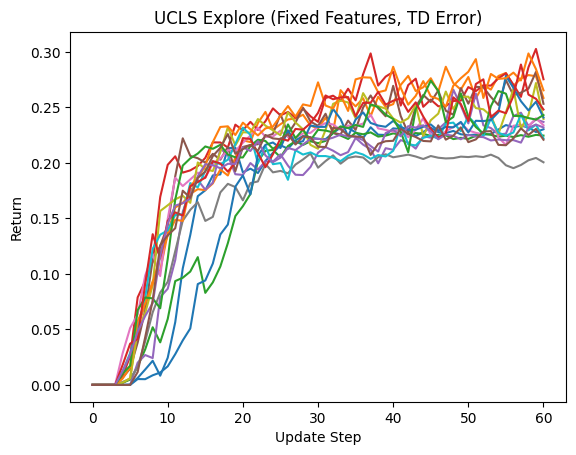

Global Mean: 0.1898164302110672
Seed-based SEM: 0.004162125755101442


In [3]:
rets = outs["metrics"]["returned_discounted_episode_returns"]
for i in range(config['N_SEEDS']):
    plt.plot(rets[i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title('UCLS Explore (Fixed Features, TD Error)')
plt.savefig('figures/UCLS Fixed Features.pdf', bbox_inches='tight')
plt.show()

# 1. Global Standard Error (Matching your .mean() calculation)
# Uses all 244 points (4 seeds * 61 updates) as samples
# rets shape is (N_SEEDS, N_UPDATES)
# 1. Calculate the mean performance for EACH seed individually
means_per_seed = rets.mean(axis=1)

# 2. Calculate Standard Error based on the number of seeds
# ddof=1 is used for sample standard deviation (unbiased estimator)
sem_seed_variance = means_per_seed.std(ddof=1) / np.sqrt(means_per_seed.size)

print(f"Global Mean: {rets.mean()}")
print(f"Seed-based SEM: {sem_seed_variance}")


In [10]:
bonus = outs["metrics"]["bonus_mean"][:,1:]
print("mean, min, and max bonus", jnp.median(bonus), bonus.min(), bonus.max())


mean, min, and max bonus 6.241913 3.4634562 46.10867


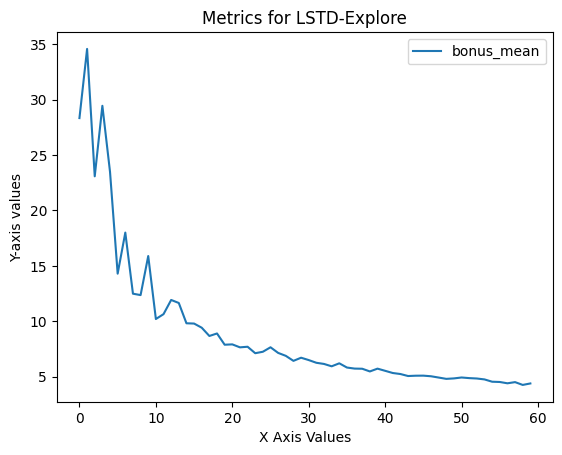

In [11]:
starting_point = 1

plt.plot(outs["metrics"]["bonus_mean"][0][starting_point:], label = 'bonus_mean')

# plt.plot(outs["metrics"]["target_embed_mean"].mean(0)[starting_point:], label = 'target_embed_mean')

# Add labels and a title for clarity
plt.xlabel('X Axis Values')
plt.ylabel('Y-axis values')
plt.title('Metrics for LSTD-Explore')
plt.legend()

# Display the plot

# plt.savefig('LSTD_Metrics.pdf', bbox_inches='tight')
plt.show()

In [4]:
outs["metrics"]["bonus_mean"][0]

Array([ 0.63463795, 28.33837   , 34.580414  , 23.081818  , 29.44665   ,
       23.485271  , 14.296695  , 18.0024    , 12.488446  , 12.361745  ,
       15.885754  , 10.201864  , 10.64094   , 11.922756  , 11.649352  ,
        9.817858  ,  9.792552  ,  9.418037  ,  8.6719675 ,  8.897953  ,
        7.8831825 ,  7.9132805 ,  7.6454144 ,  7.69991   ,  7.115764  ,
        7.2479925 ,  7.6509376 ,  7.1432533 ,  6.8787146 ,  6.4262543 ,
        6.709337  ,  6.4966745 ,  6.2523117 ,  6.147273  ,  5.9341664 ,
        6.2047157 ,  5.8234186 ,  5.72845   ,  5.7143855 ,  5.4704294 ,
        5.7232924 ,  5.5271964 ,  5.329046  ,  5.237214  ,  5.057102  ,
        5.085735  ,  5.090943  ,  5.03551   ,  4.919363  ,  4.8008833 ,
        4.842078  ,  4.9247055 ,  4.8684883 ,  4.8334885 ,  4.750495  ,
        4.5432463 ,  4.5188336 ,  4.4000916 ,  4.5065703 ,  4.253995  ,
        4.386488  ], dtype=float32)